STEP 0: Ensuring Python installed all packages

In terminal, run:
python3 -m pip install torch torchvision torchaudio matplotlib scikit-learn numpy pandas

And to use notebook, run:
python3 -m pip install notebook

then run:
jupyter notebook
To open jupyter, then go to file>new>notebook.
Using Jupyter instead of colab allows you to run blocks and more seamlessly use datasets straight from your computers

The CNN below is for binary classification (2 classes). There are some comments for where you can adjust the code to make it multi-class.

STEP 1: Importing our data

In [316]:
img_height=256
img_width=256

In [317]:
#1.1: Loading necessary add-ins
# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# TorchVision
from torchvision import datasets
from torchvision.transforms import v2

# Data utilities
from torch.utils.data import DataLoader, random_split

# Visualisation
import matplotlib.pyplot as plt
import numpy as np

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

# Miscellaneous
import os
from PIL import Image
import tqdm
import load_data
import architecture

In [318]:
#1.2: Select computing device (most likely CPU)
# Use a GPU if available, otherwise use the CPU
device = torch.device("mps")

print(f"Using device: {device}")

Using device: mps


In [319]:
#transform = v2.Compose([v2.RandomHorizontalFlip(p=0.5),v2.RandomVerticalFlip(p=0.5), v2.ScaleJitter(target_size=(img_width, img_height), scale_range=(0.7, 1.3)), v2.RandomRotation([0,360]),v2.RandomApply([v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)],0.5), v2.Resize((img_width, img_height)),v2.ToTensor()]) #converts to channel x height x width
transform1 = v2.Compose([v2.Resize((img_width, img_height))])
transform2 = v2.Compose([v2.RandomHorizontalFlip(p=0.5),v2.RandomVerticalFlip(p=0.5), v2.Resize((img_width, img_height))])
transform3 = v2.Compose([v2.ScaleJitter(target_size=(img_width, img_height), scale_range=(0.7, 1.3)), v2.Resize((img_width, img_height))])
transform4 = v2.Compose([v2.RandomRotation([0,360]), v2.Resize((img_width, img_height))])
transform5 = v2.Compose([v2.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1), v2.Resize((img_width, img_height))]) #converts to channel x height x width
transforms = [transform1, transform2, transform3, transform4, transform5]
titles = ["Original Image", "Flips", "Scale Jitter", "Random Rotation", "Color Jitter (fully augmented)"]

In [320]:
#1.4: Load dataset to workspace
train_dataset = load_data.Dataset(False, False, True, False, False, True, None)

In [321]:
#1.5: Display data info
print(f"Number of images: {len(train_dataset)}")

Number of images: 14297


Compose(    Resize(size=[256, 256], interpolation=bilinear, antialias=True))
Compose(
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.5)
      Resize(size=[256, 256], interpolation=bilinear, antialias=True)
)
Compose(
      ScaleJitter(target_size=(256, 256), scale_range=(0.7, 1.3), interpolation=bilinear, antialias=True)
      Resize(size=[256, 256], interpolation=bilinear, antialias=True)
)
Compose(
      RandomRotation(degrees=[0.0, 360.0], interpolation=nearest, expand=False, fill=0)
      Resize(size=[256, 256], interpolation=bilinear, antialias=True)
)
Compose(
      ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.6, 1.4), hue=(-0.1, 0.1))
      Resize(size=[256, 256], interpolation=bilinear, antialias=True)
)
Compose(    Resize(size=[256, 256], interpolation=bilinear, antialias=True))
Compose(
      RandomHorizontalFlip(p=0.5)
      RandomVerticalFlip(p=0.5)
      Resize(size=[256, 256], interpolation=bilinear, antialias=True)
)
Compose(
    

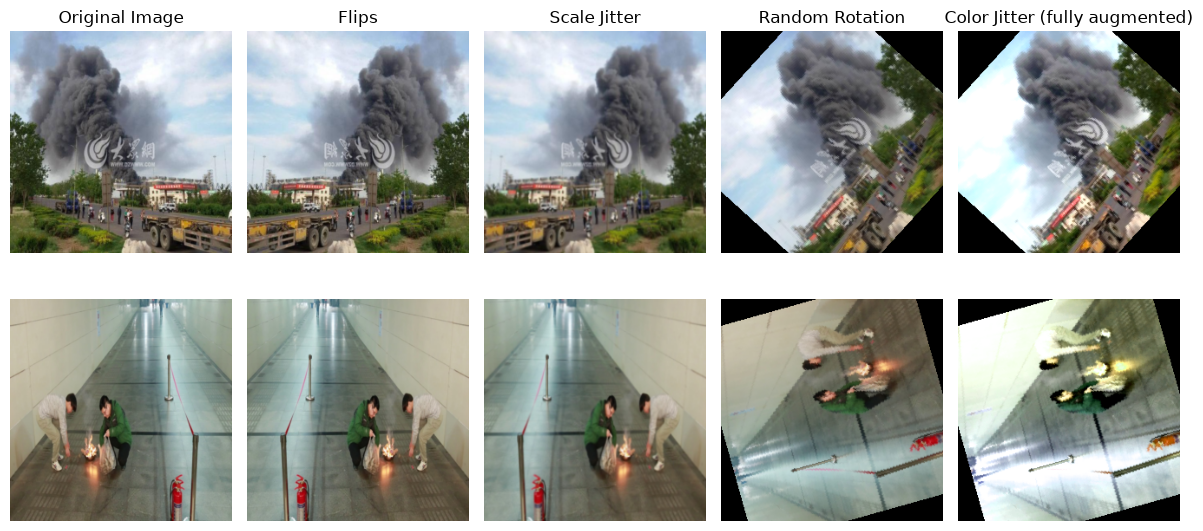

In [322]:
#1.6: Visualization
#We want to make sure it looks okay!
# Create a DataLoader to retrieve a small batch of images

# Retrieve one batch of images and labels
import random
images = []
for i in range(10):
    images.append(train_dataset.__getitem__(random.randint(0, 10000))[0])


# Create a figure
plt.figure(figsize=(12, 6))

# Display six images
for i in range(2):
    image = images[i]
    for j in range(5):
        
        ax = plt.subplot(2, 5, i * 5 + j + 1)
        print(transforms[j])
        image = transforms[j](image)
        ax.imshow(image)
        ax.axis("off")
        if i == 0:
            ax.set_title(titles[j])
        if j == 0:
            ax.set_ylabel(f"Sample {i+1}", rotation=90, size='large', labelpad=10)

plt.tight_layout()
plt.show()
